#Exercícios para entregar 4

###Aluno: Katlyn Ribeiro Almeida           
###Nusp:14586070

In [78]:
#imports necessarios
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import mode

In [79]:
#serao utilizados as bases pegando direto do drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1 - Considere os dados abaixo. Ajuste um modelo de regressão usando: regressão polinomial, k-vizinhos e árvore de decisão.

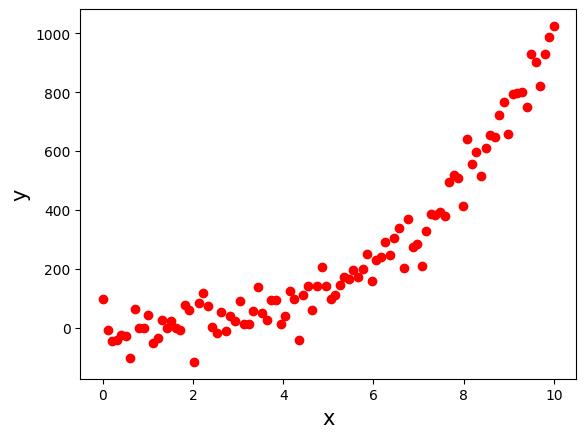

In [80]:
import numpy as np
from sklearn.linear_model import LinearRegression

N = 100
X = np.linspace(0,10,N)
y = X**3 + np.random.normal(0,50, N)
plt.plot(X,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

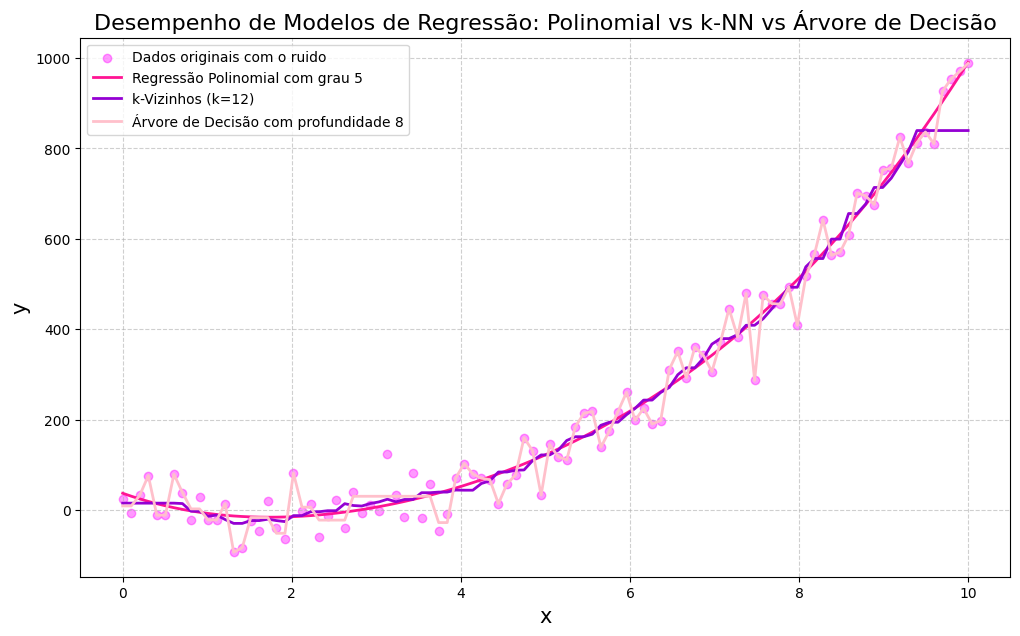

In [81]:
#codigo referente ao exercicio 1

#gerando dados sinteticos
np.random.seed(42)
#100 amostras
N = 100
#cria 100 valores igualmente espaçados entre 0 e 10 e transforma isso em uma matriz coluna
X = np.linspace(0, 10, N).reshape(-1, 1)
#entregue pelo enunciado acima, gera y = x³ + ruido
y = X**3 + np.random.normal(0, 50, (N, 1))
#transforma dado de y de matriz para vetor
y = y.flatten()

#k-Vizinhos (k=12)----------------------------------------------------------
k_modelo = KNeighborsRegressor(n_neighbors=12)
k_modelo.fit(X, y)
y_k_pred = k_modelo.predict(X)

#regressão Polinomial--------------------------------------------------------
pol_modelo = make_pipeline(PolynomialFeatures(degree=5), LinearRegression())
pol_modelo.fit(X, y)
y_pol_pred = pol_modelo.predict(X)

#arvore de Decisão--------------------------------------------------------
arvore_modelo = DecisionTreeRegressor(max_depth=8)
arvore_modelo.fit(X, y)
y_arvore_pred = arvore_modelo.predict(X)


#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(12, 7))
plt.scatter(X, y, color='magenta', alpha=0.4, label='Dados originais com o ruido')
plt.plot(X, y_pol_pred, color='deeppink', linewidth=2, label='Regressão Polinomial com grau 5')
plt.plot(X, y_k_pred, color='darkviolet', linewidth=2, label='k-Vizinhos (k=12)')
plt.plot(X, y_arvore_pred, color='pink', linewidth=2, label='Árvore de Decisão com profundidade 8')

plt.title('Desempenho de Modelos de Regressão: Polinomial vs k-NN vs Árvore de Decisão', fontsize=16)
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2 - Faça a classificação da base vertebralcolumn-3C.

In [82]:
#codigo referente ao exercicio 2

#caminho para a base vertebralcolumn-3C pelo drive-------------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/vertebralcolumn-3C.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#aqui pegamos as caracteristicas
X = data.iloc[:, :-1]
#aqui contém a classe
y = data.iloc[:, -1]

#converte valores de y em numeros inteiros
le = LabelEncoder()
y = le.fit_transform(y)

#aqui acontece a divisao para o treino e para o teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.55, random_state=42)

#aqui acontece a normalização
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste = scaler.transform(X_teste)

#treinamento
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_treino, y_treino)

#prediçao
y_pred = modelo.predict(X_teste)

#printando os valores-------------------------------------
print(f"Acurácia: {accuracy_score(y_teste, y_pred):.2%}")
print("\nClassificação:")
print(classification_report(y_teste, y_pred, target_names=le.classes_))

Acurácia: 85.38%

Classificação:
                   precision    recall  f1-score   support

           Hernia       0.73      0.53      0.62        30
           Normal       0.75      0.82      0.78        50
Spondylolisthesis       0.95      0.98      0.96        91

         accuracy                           0.85       171
        macro avg       0.81      0.78      0.79       171
     weighted avg       0.85      0.85      0.85       171



3 - Ajuste um modelo de regressão aos dados de concreto para predizer a variável concrete_compressive_strength.

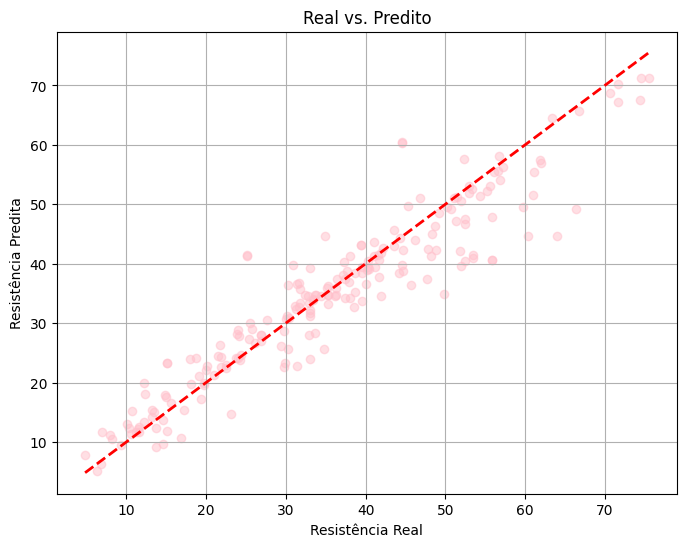

In [83]:
#codigo referente ao exercicio 3

#caminho para a base concrete_data pelo drive-----------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/concrete_data.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#a variavel x é igual a cimento, cinzas, agua, etc pertencentes a base de dados
X = data.drop('concrete_compressive_strength', axis=1)
#a variavel y é a variavel "concrete_compressive_strength"
y = data['concrete_compressive_strength']

#aqui acontece a divisao para o treino e para o teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

#treinamento
modelo_concreto = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_concreto.fit(X_treino, y_treino)

#prediçao
y_pred = modelo_concreto.predict(X_teste)

#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_teste, y_pred, alpha=0.5, color='pink')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Resistência Real')
plt.ylabel('Resistência Predita')
plt.title('Real vs. Predito')
plt.grid(True)
plt.show()


4 - Escolha uma base de dados e compare a influencia da medida de impureza na classificação (Gini, Entropia, etc).

In [84]:
#codigo referente ao exercicio 4

#caminho para a base iris pelo drive-----------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/iris.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados-------------------
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

#divisão do treino e do teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.55, random_state=42)

#comparaçao
criterios = ['gini', 'entropy', 'log_loss']
resultados = {}

for crit in criterios:
    clf = DecisionTreeClassifier(criterion=crit, max_depth=4, random_state=42)
    clf.fit(X_treino, y_treino)

    y_pred = clf.predict(X_teste)
    acc = accuracy_score(y_teste, y_pred)

    resultados[crit] = {
        'acuracia': acc,
        'Profundidade': clf.get_depth()
    }

#comparação printada-----------------------------------------------
df_resumo = pd.DataFrame(resultados).T
print(df_resumo)

          acuracia  Profundidade
gini      0.903614           4.0
entropy   0.903614           4.0
log_loss  0.903614           4.0


5 - Considere um conjunto de dados com n observações (Vehicle).
* Gere uma nova amostra de treinamento selecionando n observações de forma aleatória com reposição a
partir do conjunto de dados original. Esse procedimento é conhecido como reamostragem bootstrap.
*  Utilize essa nova amostra para treinar uma árvore de decisão.
* Repita esse processo B vezes, gerando B árvores diferentes.
* Para classificar uma nova observação x, utilize todas as árvores geradas e registre a classe prevista por
cada uma delas.
* A classificação final de x deve ser obtida pela moda das previsões das B árvores, isto é, pela classe mais
frequentemente prevista.
* Faça um gráfico de B versus a acurácia. Esse processo melhora a classificação?

Obtenha um gráfico como esse:
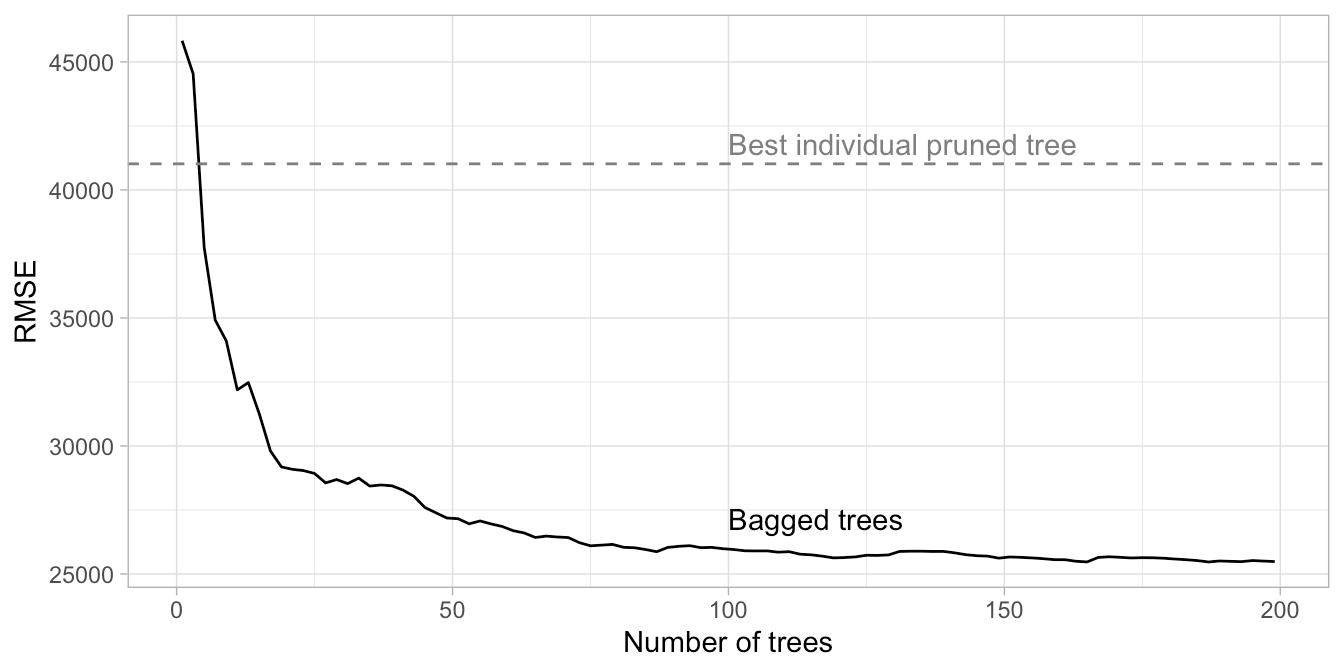

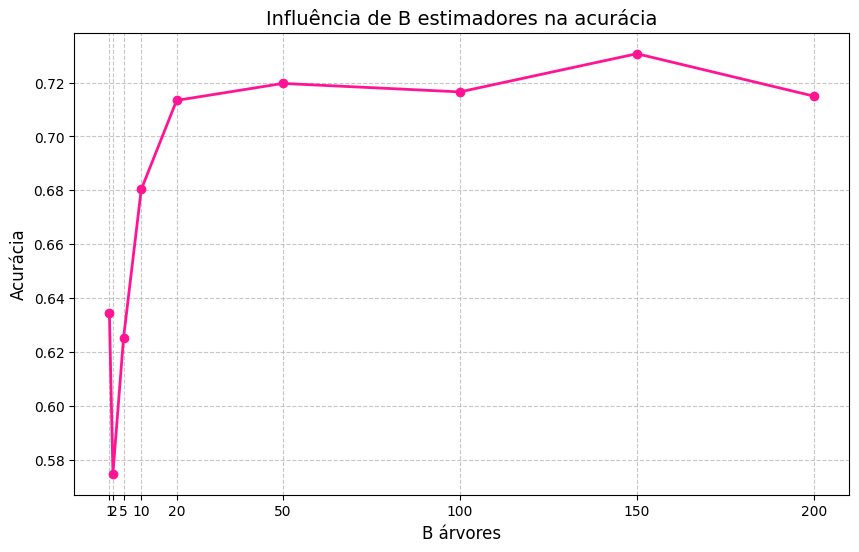

In [96]:
#codigo referente ao exercicio 5

#caminho para a base vehicle pelo drive-----------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/Vehicle.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados-------------------
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

#divisão do treino e do teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.75, random_state=42)

def reamostragem_bootstrap(B_values):
    acuracias = []

    for B in B_values:
        predicoes_acumuladas = []

        for i in range(B):
            #n observações com reposição
            n= X_treino.shape[0]
            indices = np.random.choice(n, n, replace=True)
            X_b = X_treino[indices]
            y_b = y_treino[indices]

            #teina a arvore de decisao
            clf = DecisionTreeClassifier(random_state=i)
            clf.fit(X_b, y_b)

            #predições
            predicoes_acumuladas.append(clf.predict(X_teste))

        predicoes_acumuladas = np.array(predicoes_acumuladas)
        votos_finais = []

        for j in range(predicoes_acumuladas.shape[1]):
            valores, contagem = np.unique(predicoes_acumuladas[:, j], return_counts=True)
            votos_finais.append(valores[np.argmax(contagem)])

        #calcula o valor da acuracia
        acc = accuracy_score(y_teste, votos_finais)
        acuracias.append(acc)

    return acuracias

#quantidade de arvores
B = [1, 2, 5, 10, 20, 50, 100, 150, 200]
acuracias_resultado = reamostragem_bootstrap(B)

#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(B, acuracias_resultado, marker='o', linestyle='-', color='deeppink', linewidth=2)
plt.title('Influência de B estimadores na acurácia', fontsize=14)
plt.xlabel('B árvores', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(B)
plt.show()